In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 
import numpy as np
import os, sys, ast, re

In [121]:
PATH = os.getcwd().split('/')[:-1]
PATH = "/".join(PATH)

PLOTS = os.getcwd()
RESULTS = f"{PATH}/results"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12
})


In [83]:
ibm_bv_df = pd.read_csv(f"{RESULTS}/ibm_boston_2026-01-13 15:32:22.958348.csv", header=4, skipfooter=2, engine='python')
ibm_g_df = pd.read_csv(f"{RESULTS}/ibm_boston_2026-01-13 15:59:39.491177.csv",  header=4, skipfooter=2, engine='python')

aria_bv_df = pd.read_csv(f"{RESULTS}/aria-1_2026-01-14 23:51:58.054296.csv", header=4, skipfooter=2, engine='python')
aria_g_df = pd.read_csv(f"{RESULTS}/aria-1_2026-01-15 00:06:55.145587.csv",  header=4, skipfooter=2, engine='python')

# df = pd.concat([bv_df, g_df])
aria_bv_df.head()

,problem,num_qubits,shots,end_time,time_ms,usage_estimation,results,metadata
0,Bernstein-Vazirani,4,1024,2026-01-14 23:52:03.955427,5899.448,NaN,{'011': 1024},Secret number: 011
1,Bernstein-Vazirani,4,1024,2026-01-14 23:52:15.754070,5666.628,NaN,"{'000': 1, '010': 1023}",Secret number: 010
2,Bernstein-Vazirani,4,1024,2026-01-14 23:52:27.566197,5685.877,NaN,{'010': 1024},Secret number: 010
3,Bernstein-Vazirani,4,1024,2026-01-14 23:52:39.518050,5825.879,NaN,{'000': 1024},Secret number: 000
4,Bernstein-Vazirani,4,1024,2026-01-14 23:52:51.339131,5694.988,NaN,{'011': 1024},Secret number: 011


In [84]:
def plot_hist(df, machine=None, problem=None, qubits=4, idx=0):
    r = df[df['num_qubits'] == qubits].iloc[idx]
    result = ast.literal_eval(r['results'])

    fig, ax = plt.subplots()
    bar_container = ax.bar(result.keys(), result.values(), align='center')
    ax.set(
        ylabel='Shot Count', 
        title=f'{machine} - {problem} results\n{r['metadata']}', 
        xticks=list(result.keys()),
        xticklabels=result.keys(),
    )
    ax.bar_label(bar_container, fmt='{:,.0f}')
    ax.tick_params(axis='x', rotation=45)

    plt.show()

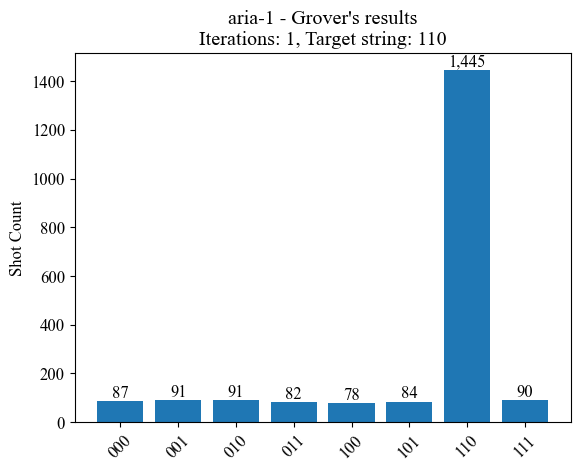

In [85]:
plot_hist(aria_g_df, "aria-1", "Grover's", 3, 0)

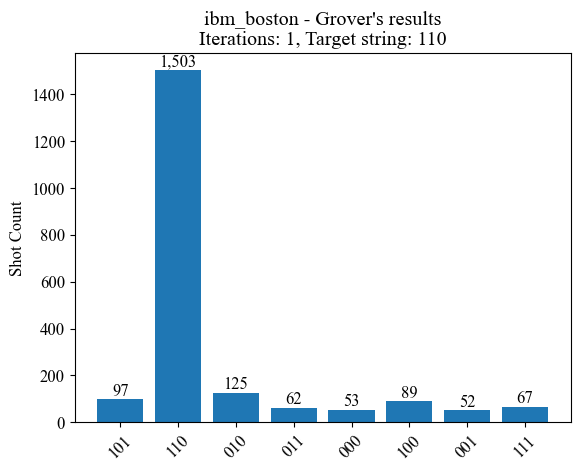

In [86]:
plot_hist(ibm_g_df, "ibm_boston", "Grover's", 3, 0)

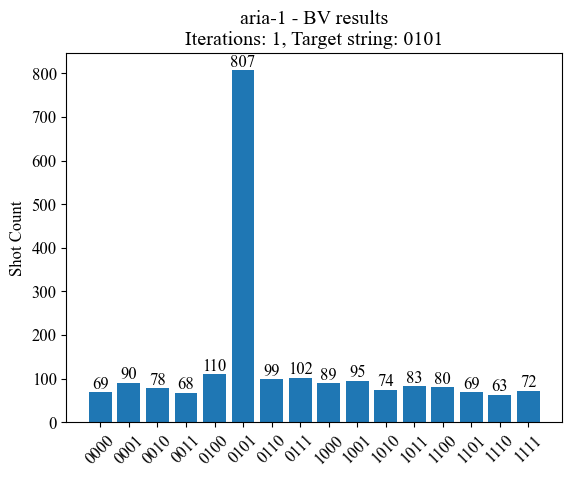

In [87]:
plot_hist(aria_g_df, "aria-1", "BV", 4, 0)

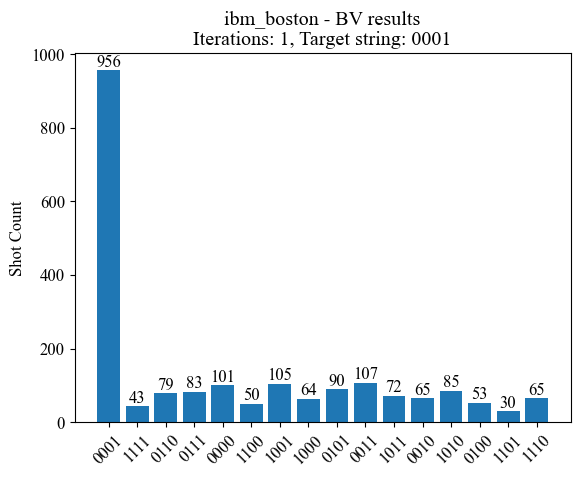

In [88]:
plot_hist(ibm_g_df, "ibm_boston", "BV", 4, 8)

In [89]:
def plot_runtimes(df, num_qubits=None, machine=None, problem=None):
    x = df['time_ms']
    y = df['end_time']
    y = [i.split(' ')[-1].split('.')[0] for i in y]

    date = df['end_time'].iloc[0].split(' ')[0]

    plt.plot(y, x)

    # 1. Get plot limits to calculate text height dynamically
    y_min, y_max = plt.ylim()
    text_y_pos = y_max - (y_max - y_min) * 0.05
    qubit_counts = df['num_qubits'].tolist()

    plt.text(x=0, y=text_y_pos, s=f"{qubit_counts[0]} Qubits", color='red', fontsize=9, rotation=90, va='top')

    # 3. Loop through the rest to find changes
    for i in range(1, len(qubit_counts)):
        if qubit_counts[i] != qubit_counts[i-1]:
            # Draw the divider line
            plt.axvline(x=i - 0.5, color='red', linestyle='--', alpha=0.6, linewidth=1)
            
            # Label the new section
            plt.text(x=i, y=text_y_pos, s=f"{qubit_counts[i]} Qubits", color='red', fontsize=9, rotation=90, va='top')

    if len(df) > 20:
        interval = 5
        tick_indices = range(0, len(y), interval)
        tick_labels = y[::interval]
        plt.xticks(tick_indices, tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    else:
        plt.xticks(rotation=45, ha='right', rotation_mode='anchor')

    qubits = f"- {num_qubits} Qubits " if len(df) <= 20 else ""

    plt.ylabel("Run Time (ms)")
    plt.xlabel("Experiment End Timestamp")
    plt.title(f"{machine} - {problem} Run Times {qubits}- {date}")

    plt.show()

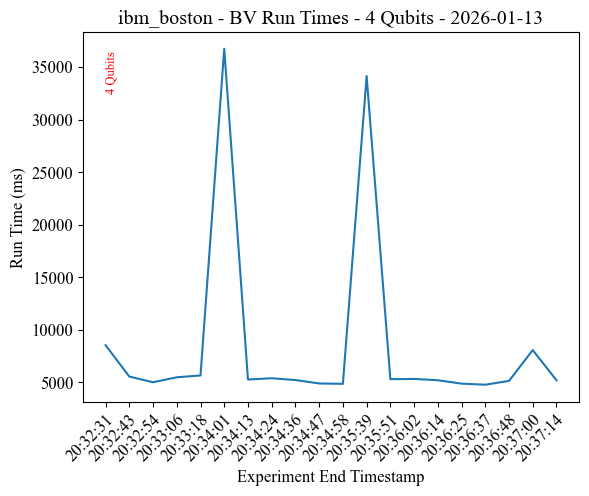

In [90]:
q = ibm_bv_df[ibm_bv_df['num_qubits'] == 4]
plot_runtimes(q, 4, "ibm_boston", "BV")

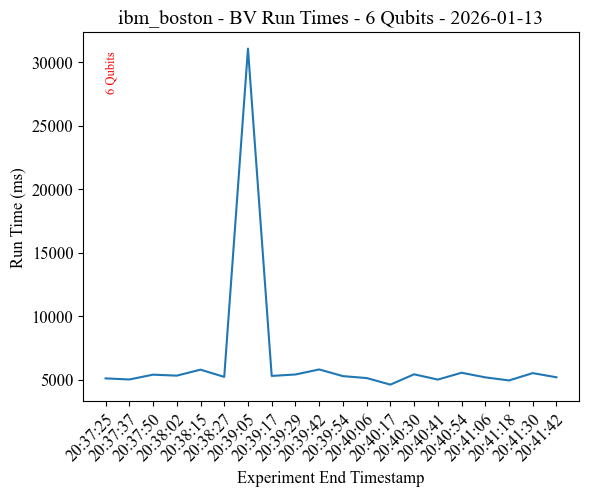

In [91]:
q = ibm_bv_df[ibm_bv_df['num_qubits'] == 6]
plot_runtimes(q, 6, "ibm_boston", "BV")

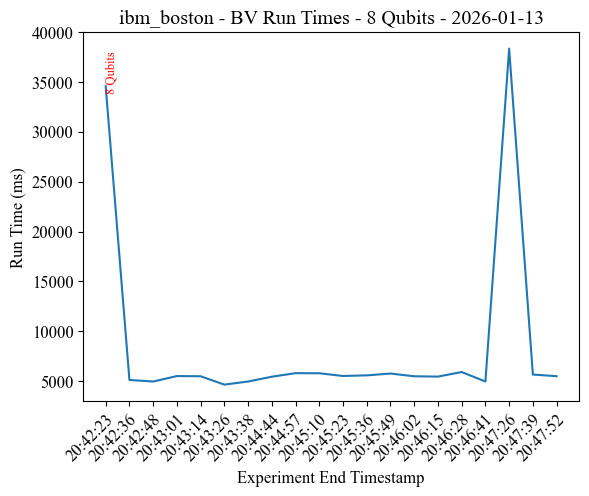

In [92]:
q = ibm_bv_df[ibm_bv_df['num_qubits'] == 8]
plot_runtimes(q, 8, "ibm_boston", "BV")

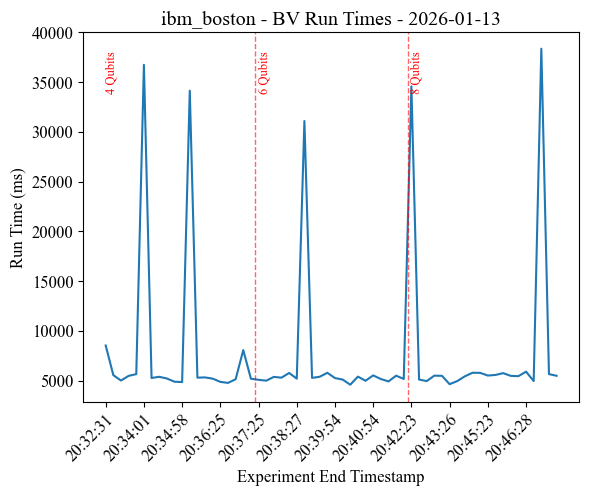

In [93]:
plot_runtimes(ibm_bv_df, 0, "ibm_boston", "BV")

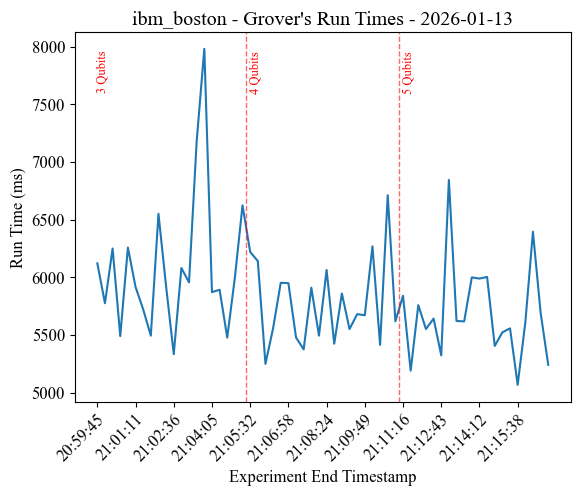

In [94]:
plot_runtimes(ibm_g_df, 0, "ibm_boston", "Grover's")

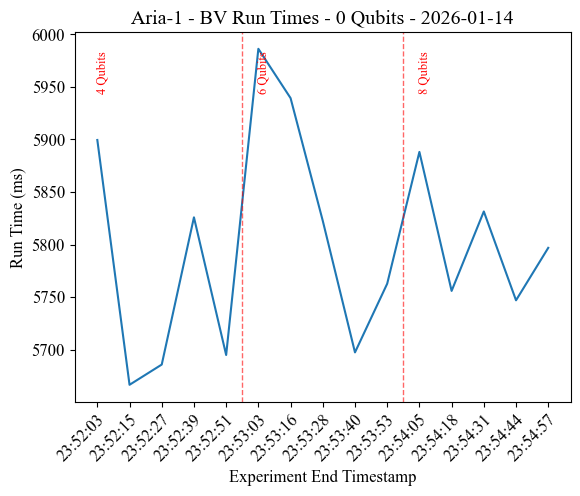

In [95]:
# aria_bv_df
plot_runtimes(aria_bv_df, 0, "Aria-1", "BV")

In [186]:
def plot_paper_quality(df, machine="IBM Boston", title=""):
    # Data Prep
    y = df['time_ms'].values
    qubit_counts = df['num_qubits'].values
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. Plot the data
    # zorder=10 ensures the line sits ON TOP of the background shading
    ax.plot(range(len(y)), y, color='#2c3e50', linewidth=1.5, label='Run Time', zorder=10)

    # 2. Setup Shaded Regions & Top Labels
    # Find indices where qubit count changes
    changes = [0] + [i for i in range(1, len(qubit_counts)) if qubit_counts[i] != qubit_counts[i-1]] + [len(qubit_counts)]
    colors = ["#dddddd", '#ffffff'] # Alternating subtle background colors
    
    # Get the transform for placing text relative to the top of the axis
    trans = ax.get_xaxis_transform()

    for k in range(len(changes) - 1):
        start = changes[k]
        end = changes[k+1]
        
        # A. Shade the background
        # We shade from (start-0.5) to (end-0.5) to perfectly frame the data points
        ax.axvspan(start - 0.5, end - 0.5, color=colors[k % 2], alpha=1, zorder=0)
        
        # B. Add Label at the top
        mid_point = (start + end - 1) / 2
        ax.text(mid_point, 0.95, f"{qubit_counts[start]} Qubits", 
                transform=trans,             # Use axis coordinates (0-1) for Y
                ha='center', va='top',       # Anchor top of text to the 0.95 line
                fontsize=10, fontweight='bold', color='#555555')

    # 3. Clean Axes & Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 4. Labeling
    ax.set_ylabel("Run Time (ms)", fontsize=11)
    ax.set_xlabel("Experiment Run Index", fontsize=11)
    
    # Snap the margins to the data limits (removes side gaps)
    ax.margins(x=0)
    
    # 5. Handle Annotations
    # Normalize string check (e.g., allow "IBM Boston" or "IBM_Boston")
    if "Boston" in machine: 
        # Note: Ensure these coordinates match your specific data spikes
        ax.annotate('Queue Delay', xy=(11, 35000), xytext=(12, 30000), 
                    arrowprops=dict(arrowstyle='->', lw=1), fontsize=9)

    ax.set_title(title)

    plt.tight_layout()
    plt.show()

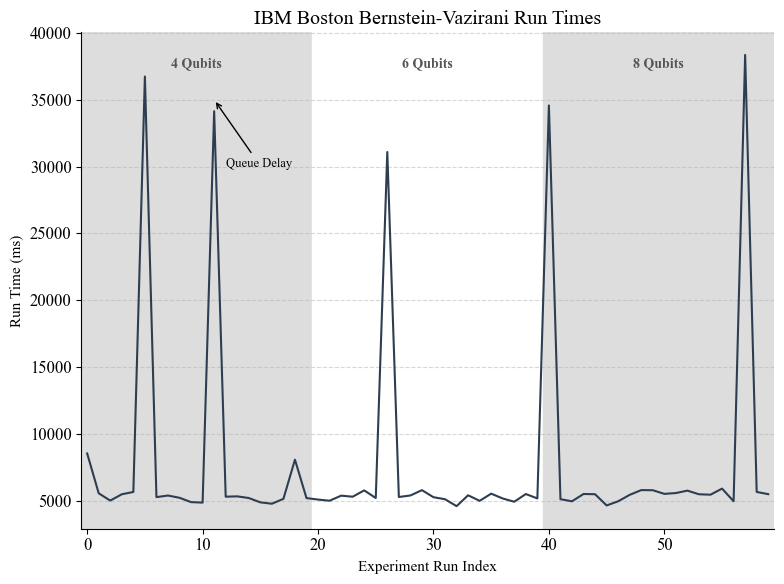

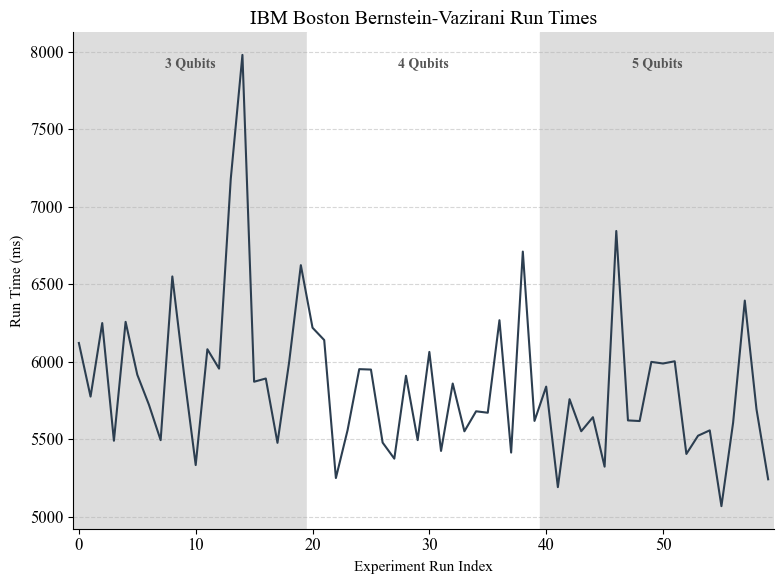

In [188]:
plot_paper_quality(ibm_bv_df, "IBM_Boston", "IBM Boston Bernstein-Vazirani Run Times")
plot_paper_quality(ibm_g_df, "IBM_Boston", "IBM Boston Bernstein-Vazirani Run Times")

In [101]:
def plot_success_boxplot(df, algorithm_name="Bernstein-Vazirani"):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Create Box Plot
    # 'num_qubits' on X, 'success_probability' on Y
    sns.boxplot(x='num_qubits', y='success_probability', data=df, color='#e0e0e0', width=0.5, linewidth=1.5, ax=ax)
    
    # Overlay individual data points (swarmplot) so reviewers see n=20 isn't fake
    sns.swarmplot(x='num_qubits', y='success_probability', data=df, color='#2c3e50', alpha=0.7, size=5, ax=ax)

    # Styling
    ax.set_xlabel("Qubit Count (Problem Size)")
    ax.set_ylabel("Success Probability")
    ax.set_ylim(-0.05, 1.05) # Keep range 0-1
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add a caption-like title at bottom if needed, or simple title
    ax.set_title(f"{algorithm_name} - Fidelity vs Scale", pad=20)
    
    plt.tight_layout()
    plt.show()

In [102]:
def plot_clean_histogram(counts, correct_bitstring, title="8 Qubits"):
    # Sort counts and take top 10 to avoid overcrowding
    sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10])
    
    keys = list(sorted_counts.keys())
    values = list(sorted_counts.values())
    
    # Color logic: Highlight the correct answer
    colors = ['#2c3e50' if k == correct_bitstring else '#b0b0b0' for k in keys]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(keys, values, color=colors)
    
    ax.set_ylabel("Shot Counts")
    ax.set_title(title)
    
    # Rotate labels for readability
    plt.xticks(rotation=45, ha='right')
    
    # Highlight the correct one
    if correct_bitstring in keys:
        idx = keys.index(correct_bitstring)
        ax.annotate("Correct", xy=(idx, values[idx]), xytext=(idx, values[idx]+50), ha='center', arrowprops=dict(arrowstyle='->'))

    plt.tight_layout()
    plt.show()

In [153]:
# 1. Load and Process Data
def process_file(filename):
    # Skip metadata header (first 5 lines)
    df = pd.read_csv(filename, header=4, skipfooter=2, engine='python')
    
    # Parse 'results' column (JSON-like string to dict)
    df['counts'] = df['results'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})
    
    # Extract Target/Secret String from Metadata
    def get_target(meta):
        if pd.isna(meta): return None
        # Try BV format then Grover format
        match = re.search(r'(?:Secret number|Target string):\s*([01]+)', meta)
        return match.group(1) if match else None

    df['target_string'] = df['metadata'].apply(get_target)
    
    # Calculate Success Probability
    def calc_prob(row):
        target = row['target_string']
        counts = row['counts']
        shots = row['shots']
        if target and target in counts:
            return counts[target] / shots
        return 0.0

    df['success_probability'] = df.apply(calc_prob, axis=1)
    return df


In [171]:
# Load your specific files
df1 = process_file(f"{RESULTS}/ibm_boston_2026-01-13 15:32:22.958348.csv")
df2 = process_file(f"{RESULTS}/ibm_boston_2026-01-13 15:59:39.491177.csv")
df = pd.concat([df1, df2], ignore_index=True)

df3 = process_file(f"{RESULTS}/aria-1_2026-01-14 23:51:58.054296.csv")
df4 = process_file(f"{RESULTS}/aria-1_2026-01-15 00:06:55.145587.csv")
df_2 = pd.concat([df3, df4], ignore_index=True)


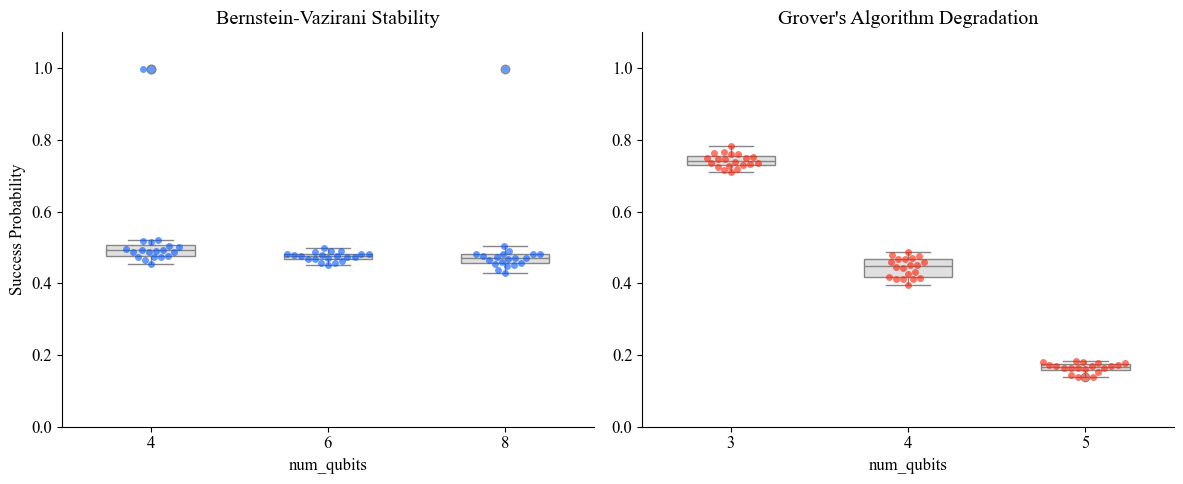

In [174]:
# --- Fidelity vs Scale (Box Plots) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BV Plot
bv_data = df[df['problem'] == 'Bernstein-Vazirani']
sns.boxplot(x='num_qubits', y='success_probability', data=bv_data, ax=axes[0], color='#e0e0e0', width=0.5)
sns.swarmplot(x='num_qubits', y='success_probability', data=bv_data, ax=axes[0], color="#0055ff", alpha=0.6)
axes[0].set_title("Bernstein-Vazirani Stability")
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Success Probability")

# Grover Plot
grover_data = df[df['problem'] == "Grover's Algorithm"]
sns.boxplot(x='num_qubits', y='success_probability', data=grover_data, ax=axes[1], color='#e0e0e0', width=0.5)
sns.swarmplot(x='num_qubits', y='success_probability', data=grover_data, ax=axes[1], color="#ff1900", alpha=0.6)
axes[1].set_title("Grover's Algorithm Degradation")
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("") 

plt.tight_layout()
plt.show()

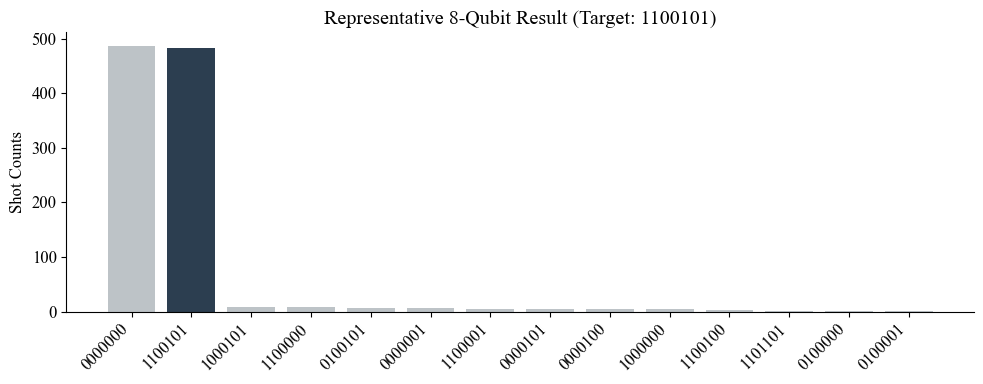

In [ ]:
# --- Representative Histogram (Median 8-Qubit BV) ---
# Find the median run
bv_8 = bv_data[bv_data['num_qubits'] == 8].sort_values('success_probability')
median_run = bv_8.iloc[len(bv_8) // 2]

# Prepare data
counts = median_run['counts']
target = median_run['target_string']
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:15]) # Top 15

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2c3e50' if k == target else '#bdc3c7' for k in sorted_counts.keys()]
ax.bar(sorted_counts.keys(), sorted_counts.values(), color=colors)

ax.set_title(f"Representative 8-Qubit Result (Target: {target})")
ax.set_ylabel("Shot Counts")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

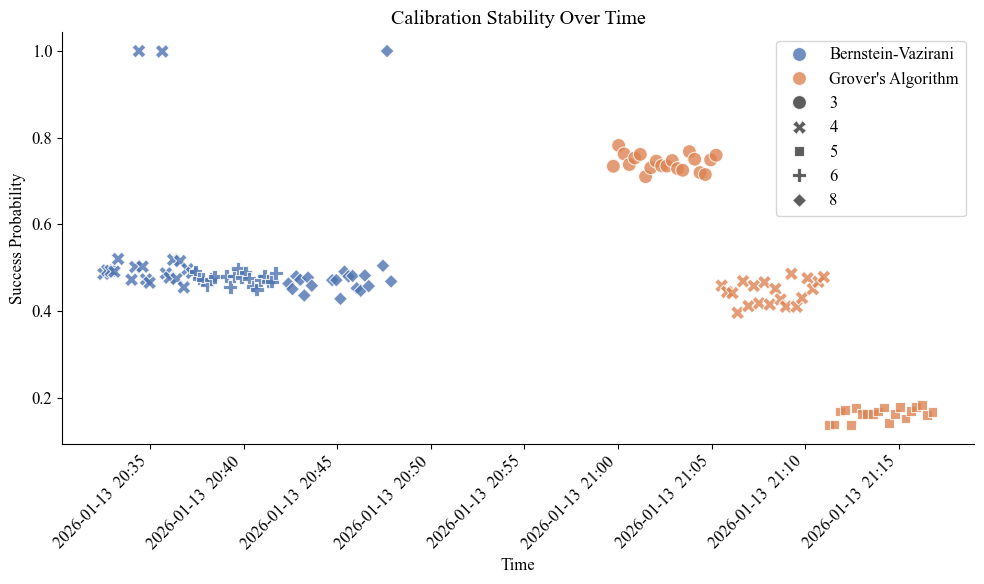

In [185]:
# IBM Boston Plot

df['end_time'] = pd.to_datetime(df['end_time'])
df = df.sort_values('end_time')

df.dropna(subset=['num_qubits'], inplace=True)
df['num_qubits'] = df['num_qubits'].astype(int)

# 2. Generate the Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='end_time', 
    y='success_probability', 
    hue='problem',       # Colors differentiate BV vs Grover
    style='num_qubits',  # Shapes differentiate 4 vs 6 vs 8 qubits
    s=100,               # Marker size
    alpha=0.8,           # Transparency
    palette='deep',
    ax=ax
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d  %H:%M'))

# FIX 2: Anchor the rotation to the 'right'
plt.xticks(rotation=45, ha='right')

# 3. Labeling
ax.set_ylabel("Success Probability")
ax.set_xlabel("Time")
ax.set_title("Calibration Stability Over Time")
plt.xticks(rotation=45)

# Get the default handles/labels
handles, labels = ax.get_legend_handles_labels()

# Create new lists excluding the headers
clean_handles = []
clean_labels = []
for h, l in zip(handles, labels):
    # Filter out the internal Seaborn titles
    if l not in ['problem', 'num_qubits']:
        clean_handles.append(h)
        clean_labels.append(l)

# Re-draw the legend with only the data items
ax.legend(clean_handles, clean_labels)#, loc='upper left')#, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()